Hola **Rodrigo**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
    <b>Respuesta:</b> 

# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [4]:
# importar librerías
import pandas as pd
import numpy as np

In [5]:

# cargar archivos
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')


In [6]:
# explorar datasets
orders.head()
orders.info()

catalog.head()
catalog.info()

marketing.head()
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
--- 

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien hecha la revisión inicial de los datos. Siempre es importante realizar una revisión general de los mismos para entender que es lo que se debe hacer en la parte de procesamiento previo al análisis cómo tal.
</div>

---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

In [7]:
# Convertir fechas
orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'], errors='coerce')
marketing['fecha'] = pd.to_datetime(marketing['fecha'], errors='coerce')

In [8]:
# Revisar valores numéricos
orders[['cantidad', 'precio_unitario', 'monto_descuento', 'monto_total']].describe()
catalog[['costo_unitario']].describe()
marketing[['gasto']].describe()

,gasto
count,1620.00000
mean,1772.74292
std,734.43294
min,501.11000
25%,1128.03000
50%,1782.42500
75%,2420.68500
max,2999.36000


In [9]:
# Verificar consistencia de montos
orders['check_total'] = (orders['cantidad'] * orders['precio_unitario']) - orders['monto_descuento']

In [10]:
# Duplicados
orders.duplicated().sum()
catalog.duplicated().sum()
marketing.duplicated().sum()

0

In [11]:
# Variables categóricas
orders[['pais', 'dispositivo', 'fuente_referencia', 'categoria_producto']].nunique()
catalog[['categoria_producto', 'proveedor']].nunique()
marketing[['pais', 'canal']].nunique()

pais     3
canal    3
dtype: int64

---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [12]:

# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)


---

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien, seguiste el paso a paso de tu proyecto de una manera adecuada. Realizando el procesamiento y limpieza ideal para poder tener análisis y hallazgos correctos para luego presentarlos ante el negocio que lo solicitó.
</div>

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? El ingreso total del negocio es de 52,024,257.56.
- ¿Cuál es el costo total? El costo total de los productos vendidos es de 43,140,620.46.
- ¿Cuánto se ha invertido en marketing? La inversión total en marketing es de 2,871,843.53.
- ¿El negocio es rentable? (calcular profit) Sí, el negocio es rentable. El profit total es de 6,011,793.57, lo que indica que los ingresos superan tanto los costos como la inversión en marketing.

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? El ticket promedio por orden es de 2,072.68. Esto indica el valor promedio que los clientes gastan en cada compra.
- ¿Cuál es la cantidad promedio de productos por orden? La cantidad promedio de productos por orden es de 7.09. Esto sugiere que los usuarios tienden a comprar múltiples productos en cada pedido.
- ¿Cuál es el producto más vendido? El producto más vendido es Laptop-Gaming-16GB. Esto indica una alta demanda en productos tecnológicos de alto valor.
- ¿Cuánto se ha gastado en marketing por canal? Organic: 913,533.01, Paid Search: 863,088.21, Social: 918,043.21
La inversión está distribuida de forma bastante equilibrada entre los canales, con una ligera mayor inversión en Social y Organic.

**Conclusión**

El negocio es rentable y presenta un buen ticket promedio, sin embargo, la inversión en marketing está distribuida de forma homogénea, lo que abre oportunidad para optimizar el retorno por canal.

In [13]:
# unir orders con catalog para obtener costos
df = orders.merge(catalog, on='nombre_producto', how='left')

In [14]:
# cálculos principales
revenue_total = df['monto_total'].sum()
costo_total = (df['cantidad'] * df['costo_unitario']).sum()
marketing_total = marketing['gasto'].sum()
profit = revenue_total - costo_total - marketing_total

In [15]:
# comportamiento de ventas
ticket_promedio = df['monto_total'].mean()
cantidad_promedio = df['cantidad'].mean()
producto_mas_vendido = df.groupby('nombre_producto')['cantidad'].sum().idxmax()
marketing_por_canal = marketing.groupby('canal')['gasto'].sum()

In [16]:
# prints
print("Revenue total:", revenue_total)
print("Costo total:", costo_total)
print("Marketing total:", marketing_total)
print("Profit:", profit)

print("Ticket promedio:", ticket_promedio)
print("Cantidad promedio:", cantidad_promedio)
print("Producto más vendido:", producto_mas_vendido)

print("Marketing por canal:")
print(marketing_por_canal)


Revenue total: 52024257.55999998
Costo total: 43140620.46000001
Marketing total: 2871843.53
Profit: 6011793.569999972
Ticket promedio: 2072.679584063744
Cantidad promedio: 7.092734530938124
Producto más vendido: Laptop-Gaming-16GB
Marketing por canal:
canal
organic        913533.01
paid_search    863088.21
social         918043.21
Name: gasto, dtype: float64


In [17]:
import matplotlib.pyplot as plt

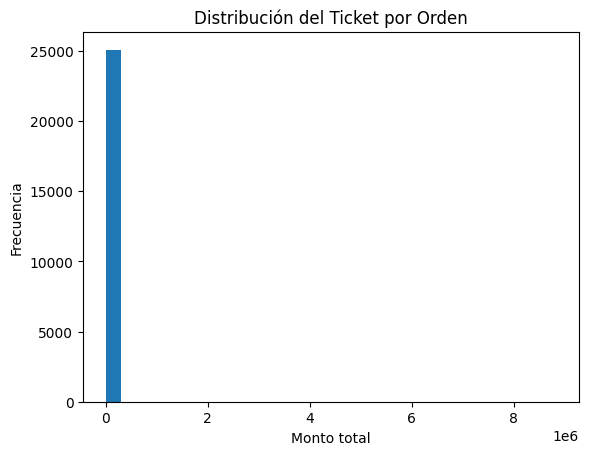

In [18]:
# Distribución del Ticket Promedio
plt.figure()
plt.hist(df['monto_total'], bins=30)
plt.title('Distribución del Ticket por Orden')
plt.xlabel('Monto total')
plt.ylabel('Frecuencia')
plt.show()

---

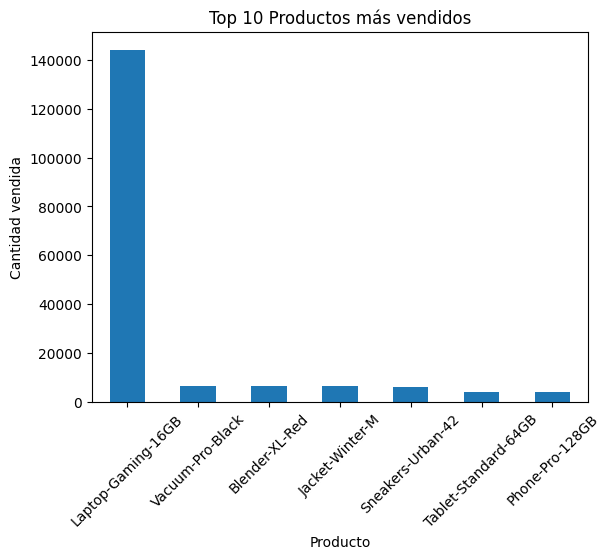

In [19]:
# Producto más vendido
top_productos = df.groupby('nombre_producto')['cantidad'].sum().sort_values(ascending=False)

plt.figure()
top_productos.head(10).plot(kind='bar')
plt.title('Top 10 Productos más vendidos')
plt.xlabel('Producto')
plt.ylabel('Cantidad vendida')
plt.xticks(rotation=45)
plt.show()

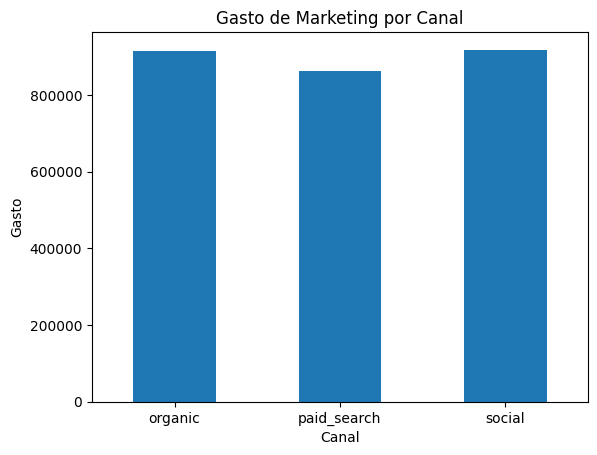

In [20]:
# Marketing por canal
plt.figure()
marketing_por_canal.plot(kind='bar')
plt.title('Gasto de Marketing por Canal')
plt.xlabel('Canal')
plt.ylabel('Gasto')
plt.xticks(rotation=0)
plt.show()

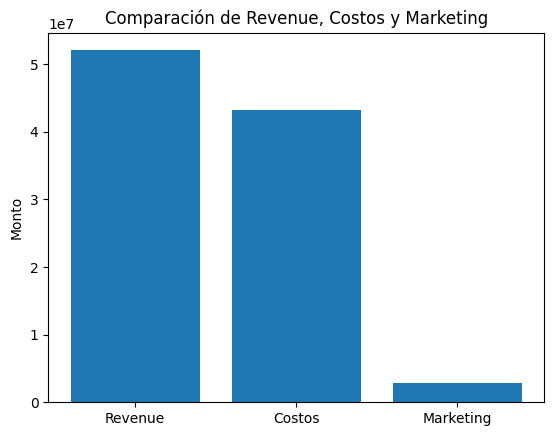

In [21]:
# Revenue vs Costos
valores = [revenue_total, costo_total, marketing_total]

plt.figure()
plt.bar(['Revenue', 'Costos', 'Marketing'], valores)
plt.title('Comparación de Revenue, Costos y Marketing')
plt.ylabel('Monto')
plt.show()

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Para el paso 2 lo ideal sería revisar las variables con gráficas siguiendo el objetivo del paso y lo que le interesa a la empresa revisar. Siempre una gráfica es mucho mejor que sólo mostrar valores numéricos, por ejemplo para la pregunta del ticket promedio podrías también mostrar la distribución ticket usando un histograma y así con el resto de preguntas escogiendo la visualización adecuada del aso.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>

Perfecto, de esta forma el proceso de análisis queda mucho más claro en cuanto al paso a paso que seguiste para anlizar cada parte de tus datos.
</div>

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel? First Visit: 8,000 usuarios, Select Item: 7,582 usuarios, Add to Cart: 7,233 usuarios, Begin Checkout: 6,520 usuarios, Add Payment Info: 5,093 usuarios, Purchase: 3,962 usuarios.
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario. El orden correcto del funnel es:
First Visit → Select Item → Add to Cart → Begin Checkout → Add Payment Info → Purchase
Esto representa el recorrido típico de un usuario desde que entra a la plataforma hasta que completa una compra.

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel. First Visit → Select Item: 94.78%, Select Item → Add to Cart: 95.40%, Add to Cart → Begin Checkout: 90.14% y 
Begin Checkout → Add Payment Info: 78.11% y Add Payment Info → Purchase: 77.79%
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios. El mayor drop-off ocurre en Begin Checkout → Add Payment Info. Aquí se pierde aproximadamente el 22% de los usuarios, lo que indica una fricción importante en el proceso de pago.
- ¿Cuál es la tasa de conversión final? La conversión final del funnel es 49.53% Esto significa que aproximadamente la mitad de los usuarios que inician el proceso terminan realizando una compra.

**Conclusión** 

El funnel muestra un buen desempeño en las primeras etapas, pero existe una caída significativa en el proceso de checkout, lo que sugiere oportunidades claras de mejora en la experiencia de pago para incrementar la conversión total.

---

In [22]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [23]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [24]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT 
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios
FROM events
GROUP BY nombre_evento
ORDER BY usuarios DESC;
'''
totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,usuarios
0,first_visit,7796
1,add_to_cart,7634
2,select_item,7582
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


In [27]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH usuarios_eventos AS (
    SELECT 
        id_usuario,
        MAX(CASE WHEN nombre_evento = 'first_visit' THEN 1 ELSE 0 END) AS first_visit,
        MAX(CASE WHEN nombre_evento = 'select_item' THEN 1 ELSE 0 END) AS select_item,
        MAX(CASE WHEN nombre_evento = 'add_to_cart' THEN 1 ELSE 0 END) AS add_to_cart,
        MAX(CASE WHEN nombre_evento = 'begin_checkout' THEN 1 ELSE 0 END) AS begin_checkout,
        MAX(CASE WHEN nombre_evento = 'add_payment_info' THEN 1 ELSE 0 END) AS add_payment_info,
        MAX(CASE WHEN nombre_evento = 'purchase' THEN 1 ELSE 0 END) AS purchase
    FROM events
    GROUP BY id_usuario
),

funnel AS (
    SELECT 
        COUNT(*) AS first_visit,
        COUNT(*) FILTER (WHERE select_item = 1) AS select_item,
        COUNT(*) FILTER (WHERE select_item = 1 AND add_to_cart = 1) AS add_to_cart,
        COUNT(*) FILTER (WHERE select_item = 1 AND add_to_cart = 1 AND begin_checkout = 1) AS begin_checkout,
        COUNT(*) FILTER (WHERE select_item = 1 AND add_to_cart = 1 AND begin_checkout = 1 AND add_payment_info = 1) AS add_payment_info,
        COUNT(*) FILTER (WHERE select_item = 1 AND add_to_cart = 1 AND begin_checkout = 1 AND add_payment_info = 1 AND purchase = 1) AS purchase
    FROM usuarios_eventos
)

SELECT 
    first_visit,
    select_item,
    add_to_cart,
    begin_checkout,
    add_payment_info,
    purchase,

    select_item * 1.0 / first_visit AS conv_1,
    add_to_cart * 1.0 / select_item AS conv_2,
    begin_checkout * 1.0 / add_to_cart AS conv_3,
    add_payment_info * 1.0 / begin_checkout AS conv_4,
    purchase * 1.0 / add_payment_info AS conv_5,

    purchase * 1.0 / first_visit AS conversion_final

FROM funnel;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,first_visit,select_item,add_to_cart,begin_checkout,add_payment_info,purchase,conv_1,conv_2,conv_3,conv_4,conv_5,conversion_final
0,8000,7582,7233,6520,5093,3962,0.94775,0.95397,0.901424,0.781135,0.77793,0.49525


<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Aquí te pediría revisar la lógica en la query ya que una conversión no puede ser de más del 100% y en tu caso hay un evento que tiene valores mayores a 1 que sería el equivalente a más del 100%. 

También hace falta que redactes tu propio análisis de cada uno de los resultados que estás presentando, esto lo deberías hacer en una celda markdown.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>

Excelente, de esta forma los resultados van más acorde a lo que se espera de un proyecto cómo este. Buen trabajo con los cambios en la query
</div>

---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [28]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [29]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [30]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
WITH cohortes AS (
    SELECT 
        id_usuario,
        DATE_TRUNC('month', CAST(fecha_registro AS DATE)) AS cohorte
    FROM users
),
actividad AS (
    SELECT 
        id_usuario,
        dias_despues_registro,
        activo
    FROM user_activity
),
base AS (
    SELECT 
        c.cohorte,
        a.id_usuario,
        a.dias_despues_registro,
        a.activo
    FROM cohortes c
    JOIN actividad a 
        ON c.id_usuario = a.id_usuario
),
retencion AS (
    SELECT 
        cohorte,
        COUNT(DISTINCT id_usuario) AS usuarios_iniciales,
        COUNT(DISTINCT CASE WHEN dias_despues_registro BETWEEN 1 AND 7 AND activo = 1 THEN id_usuario END) AS retenido_w1,
        COUNT(DISTINCT CASE WHEN dias_despues_registro BETWEEN 8 AND 14 AND activo = 1 THEN id_usuario END) AS retenido_w2,
        COUNT(DISTINCT CASE WHEN dias_despues_registro BETWEEN 15 AND 21 AND activo = 1 THEN id_usuario END) AS retenido_w3
    FROM base
    GROUP BY cohorte
)
SELECT 
    cohorte,
    usuarios_iniciales,
    retenido_w1,
    retenido_w2,
    retenido_w3,
    retenido_w1 * 1.0 / usuarios_iniciales AS semana_1,
    retenido_w2 * 1.0 / usuarios_iniciales AS semana_2,
    retenido_w3 * 1.0 / usuarios_iniciales AS semana_3
FROM retencion
ORDER BY cohorte;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohorte,usuarios_iniciales,retenido_w1,retenido_w2,retenido_w3,semana_1,semana_2,semana_3
0,2025-01-01 00:00:00+00:00,1627,697,668,656,0.428396,0.410572,0.403196
1,2025-02-01 00:00:00+00:00,1444,611,609,635,0.423130,0.421745,0.439751
2,2025-03-01 00:00:00+00:00,1636,677,705,690,0.413814,0.430929,0.421760
3,2025-04-01 00:00:00+00:00,1606,680,697,663,0.423412,0.433998,0.412827
4,2025-05-01 00:00:00+00:00,1687,695,676,706,0.411974,0.400711,0.418494


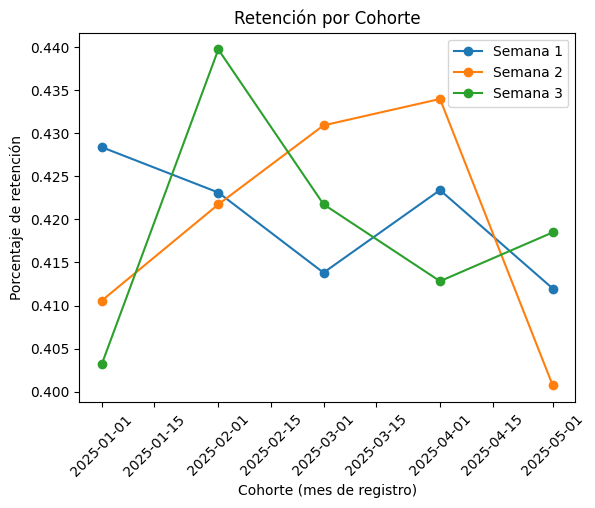

In [31]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(cohorte_final['cohorte'], cohorte_final['semana_1'], marker='o', label='Semana 1')
plt.plot(cohorte_final['cohorte'], cohorte_final['semana_2'], marker='o', label='Semana 2')
plt.plot(cohorte_final['cohorte'], cohorte_final['semana_3'], marker='o', label='Semana 3')

plt.title('Retención por Cohorte')
plt.xlabel('Cohorte (mes de registro)')
plt.ylabel('Porcentaje de retención')
plt.legend()

plt.xticks(rotation=45)
plt.show()

**Análisis de Retención por Cohortes**
**Comportamiento general**

La retención de usuarios se mantiene relativamente estable a lo largo de las cohortes analizadas.
En promedio, entre el 40% y 43% de los usuarios regresan en las primeras semanas después de registrarse.

**Retención por semana**
Semana 1: ~41% - 43%
Semana 2: ~40% - 43%
Semana 3: ~40% - 44%

Esto indica que la caída de usuarios no es abrupta, sino que se mantiene consistente en el tiempo.

**Comparación entre cohortes**

No se observan mejoras significativas entre cohortes más recientes, lo que sugiere que no ha habido cambios relevantes en la retención a lo largo del tiempo

**Insight clave**

Aunque la retención es estable, se mantiene en niveles relativamente bajos (~40%), lo que indica que más de la mitad de los usuarios no regresan después del registro

**Recomendaciones**
- Mejorar onboarding del usuario
- Implementar estrategias de reactivación
- Incentivar primeras compras o interacciones
- Personalización de experiencia

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Perfecto la query y los resultados presentados. Lo único que recomendaría aquí es tratar de llevarlo a algo más visual para que sea más fácil de explicar y entender
</div>

---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** No existe diferencia en la tasa de conversión entre la variante control y la variante tratamiento.
   - **H₁ (Hipótesis alternativa):** Existe una diferencia en la tasa de conversión entre la variante control y la variante tratamiento.
   
**Test estadístico:** Se utiliza un t-test para muestras independientes (independent samples t-test), ya que se comparan dos grupos distintos (control vs tratamiento) en una variable numérica binaria (conversión). 
**Nivel de significancia alpha:** alpha = 0.05
Esto significa que aceptamos un 5% de probabilidad de error al rechazar la hipótesis nula.

In [33]:
# cargar dataset
exp = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')

# tasas de conversión por grupo
conversion = exp.groupby('variante')['convirtio'].agg(['mean', 'count'])

# separar grupos
control = exp[exp['variante'] == 'control']['convirtio']
tratamiento = exp[exp['variante'] == 'tratamiento']['convirtio']

# test estadístico
from scipy import stats

stat, p_value = stats.ttest_ind(tratamiento, control)

# hipótesis
print("H0: No hay diferencia en la tasa de conversión")
print("H1: Sí hay diferencia en la tasa de conversión")

# alpha
alpha = 0.05

# resultados
print("p-value:", p_value)

if p_value < alpha:
    print("Rechazamos H0: hay diferencia significativa")
else:
    print("No se rechaza H0: no hay evidencia suficiente")

conversion

H0: No hay diferencia en la tasa de conversión
H1: Sí hay diferencia en la tasa de conversión
p-value: 0.4161090861105622
No se rechaza H0: no hay evidencia suficiente


,mean,count
variante,,
control,0.156898,4965
tratamiento,0.162860,5035


<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Correcto, la aplicación de pruebas estadísticas en cuanto a código es correcta. Pero hace falta que redactes tu comentario con tu análisis de esta parte.
</div>

**Análisis del experimento A/B (Checkout UI)**

**Objetivo**

Evaluar si el rediseño del checkout (variante tratamiento) mejora la tasa de conversión en comparación con la versión actual (control).

**Resultados del experimento**

- Control: 15.69%
- Tratamiento: 16.29%

La variante tratamiento muestra una conversión ligeramente mayor.

**Resultado del test estadístico**

p-value: 0.416
Nivel de significancia (alpha): 0.05

Dado que: p-value > alpha

No se rechaza la hipótesis nula.

**Interpretación estadística**

No existe evidencia estadísticamente significativa para afirmar que la nueva versión del checkout mejora la tasa de conversión.
Aunque el grupo tratamiento presenta una ligera mejora, esta diferencia puede deberse al azar.

**Insight clave**

El cambio en la UI no generó un impacto real medible en conversión

- Esto es importante porque no todo cambio en producto genera impacto
- Se evita tomar decisiones basadas en diferencias pequeñas

**Recomendación**
    
- No implementar el cambio de manera definitiva
- Probar nuevas mejoras en el checkout
- Analizar otros factores (UX, tiempos de carga, métodos de pago)
- Considerar repetir el experimento con más datos

**Conclusión**

Aunque el tratamiento muestra una ligera mejora, no existe evidencia suficiente para justificar un cambio en el producto desde una perspectiva estadística.

**Conclusiones y recomendaciones finales**

**Conclusiones generales**
A lo largo del análisis del servicio RappiPlus, se identificaron los siguientes hallazgos clave:

**Rentabilidad del negocio**
El negocio es actualmente rentable, generando un profit positivo. Sin embargo, los costos y el gasto en marketing representan una parte significativa del revenue, por lo que la eficiencia es clave para mantener la rentabilidad.

**Funnel de conversión**
El funnel muestra un buen desempeño en las primeras etapas, con altas tasas de interacción. No obstante, existe una caída importante en la etapa de checkout, específicamente antes de ingresar la información de pago. Esto indica una fricción relevante en el proceso de compra.

**Retención de usuarios**
La retención se mantiene estable entre cohortes, con aproximadamente 40% de usuarios activos en las primeras semanas. Esto sugiere que más de la mitad de los usuarios no regresan después del registro.

**Experimentación (A/B test)**
El rediseño del checkout no mostró un impacto estadísticamente significativo en la tasa de conversión. Las diferencias observadas pueden explicarse por variabilidad aleatoria.

**Problemas clave detectados**

- Fricción en el proceso de pago
- Baja retención de usuarios
- Cambios en producto sin impacto medible
- Alta dependencia del gasto en marketing

**Recomendaciones estratégicas**

1. Optimizar el checkout, simplificar el proceso de pago, reducir pasos innecesarios y mejorar confianza (seguridad, transparencia de precios). Esto puede impactar directamente en revenue.

2. Mejorar la retención, estrategias de onboarding más efectivas, incentivos para primeras compras y campañas de reactivación. Retener usuarios es más rentable que adquirir nuevos.

3. Fortalecer la experimentación, diseñar tests con hipótesis claras, asegurar tamaño de muestra suficiente y medir impacto antes de implementar cambios.

4. Optimizar inversión en marketing, analizar ROI por canal, priorizar canales más eficientes y reducir gasto en canales menos rentables.


**Conclusión final**

- El negocio tiene una base sólida y rentable, pero existen oportunidades claras de mejora en conversión y retención.
- Enfocarse en optimizar el checkout y mejorar la experiencia del usuario puede generar un impacto significativo en el crecimiento del negocio.
- Las oportunidades de mayor impacto se encuentran en la optimización del funnel y la retención, más que en la adquisición de nuevos usuarios.

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard

In [22]:
https://drive.google.com/drive/folders/1nc-4GWesgkQ9Sym1PLxP7I9Qfw-W7iA1?usp=sharing

SyntaxError: invalid syntax (1435190795.py, line 1)

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Tienes un muy buen avance de tu proyecto en cuanto a código Rodrigo, pero hace falta la parte de story telling que cómo profesional de datos siempre se debe tener. Es decir, usando celdas markdown se debe ir redactando el análisis que vas realizando de los diferentes resultados y de esta forma comunicar de manera adecuada que es lo que se está analizando y por qué.

También, al final deberías tener una sección con conclusiones y recomendaciones generales que puedas darle a la empresa en base a los diferentes pasos realizados a lo largo de tu notebook.

Si tienes dudas o dificultades recuerda que puedes contactar a tu Success Manager o a tu tutor para solventarlas.

Saludos!
</div>

<div class="alert alert-block alert-success">
<b>Comentario general (2da Iteracion)</b> <a class=“tocSkip”></a>

**¡Te felicito por el trabajo realizado Rodrigo!** 

El paso a paso seguido en el proceso de análisis del proyecto quedó super claro y se ajusta a las necesidades del negocio presentadas. Recuerda que un buen análisis siempre debe tener una buena parte técnica que ayude a comprender la parte de negocio y los beneficios del mismo.<!--  -->

Con este proyecto demuestras las habilidades adquiridas durante tu formación, se nota tu capacidad de contar historias con datos con la excelente presentación realizada que súper fácil de entender lo cual es una habilidad super importante cómo analista de datos, el saber comunicar de manera sencilla y eficiente los resultados de tus análisis.
    
Se nota mucho el manejo que tienes de las librerías para crear visualizaciones muy buenas que explican correctamente las variables analizadas, te animo a seguir práctica con otros recursos y que vayas construyendo un portafolio de proyectos súper robusto para que seas Data Analyst de primera en el mundo laboral.
   
Saludos!
</div>